In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import copy
import random

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing on device: {device}")

Executing on device: cpu


In [5]:
class SiameseNetwork(nn.Module):
    def __init__(self, input_features=2, hidden_size=64, latent_dim=128):
        super(SiameseNetwork, self).__init__()
        
        self.conv_layer = nn.Sequential(
            nn.Conv1d(in_channels=input_features, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(64)
        )
        
        self.gru = nn.GRU(input_size=64, hidden_size=hidden_size, batch_first=True)
        
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, latent_dim),
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.conv_layer(x)
        x = x.transpose(1, 2)
        _, hidden = self.gru(x)
        embedding = self.fc(hidden.squeeze(0))
        
        return embedding

In [7]:
class HardMiningKeystrokeDataset(Dataset):
    def __init__(self, df, seq_length=20, feature_cols=['DWELL_TIME', 'FLIGHT_TIME'], num_negatives=5):
        self.seq_length = seq_length
        self.feature_cols = feature_cols
        self.num_negatives = num_negatives
        
        self.user_data = {}
        self.users = df['SUBJECT_ID'].unique()
        
        print("Extracting sliding windows for Hard Mining...")
        for user in self.users:
            user_df = df[df['SUBJECT_ID'] == user]
            features = user_df[self.feature_cols].values
            
            windows = []
            for i in range(len(features) - self.seq_length):
                windows.append(features[i : i + self.seq_length])
            
            if len(windows) > self.num_negatives: # Ensure enough data
                self.user_data[user] = torch.tensor(np.array(windows), dtype=torch.float32)
                
        self.users = list(self.user_data.keys())
        self.num_samples = sum([len(v) for v in self.user_data.values()])

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        anchor_user = random.choice(self.users)
        user_windows = self.user_data[anchor_user]
        
        idx_a, idx_p = random.sample(range(len(user_windows)), 2)
        anchor = user_windows[idx_a]
        positive = user_windows[idx_p]
        
        negatives = []
        for _ in range(self.num_negatives):
            negative_user = random.choice(self.users)
            while negative_user == anchor_user:
                negative_user = random.choice(self.users)
                
            negative_windows = self.user_data[negative_user]
            idx_n = random.randint(0, len(negative_windows) - 1)
            negatives.append(negative_windows[idx_n])
            
        negatives_tensor = torch.stack(negatives)
        
        return anchor, positive, negatives_tensor

In [9]:
df = pd.read_csv("aalto_cleaned_data.csv")

print("--- Initializing Zero-Shot Data Split ---")
all_unique_users = df['SUBJECT_ID'].unique()
np.random.shuffle(all_unique_users)

split_idx = int(len(all_unique_users) * 0.8)
train_users = all_unique_users[:split_idx]
val_users = all_unique_users[split_idx:]

print(f"Total Unique Users: {len(all_unique_users)}")
print(f"Training Users: {len(train_users)}")
print(f"Validation Users (Zero-Shot): {len(val_users)}")

train_df = df[df['SUBJECT_ID'].isin(train_users)]
val_df = df[df['SUBJECT_ID'].isin(val_users)]

batch_size = 128

train_dataset = HardMiningKeystrokeDataset(train_df, seq_length=20, num_negatives=5)
val_dataset = HardMiningKeystrokeDataset(val_df, seq_length=20, num_negatives=5)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, drop_last=True)

print(f"Train Batches per Epoch: {len(train_loader)}")
print(f"Val Batches per Epoch: {len(val_loader)}")

--- Initializing Zero-Shot Data Split ---
Total Unique Users: 46
Training Users: 36
Validation Users (Zero-Shot): 10
Extracting sliding windows for Hard Mining...
Extracting sliding windows for Hard Mining...
Train Batches per Epoch: 206
Val Batches per Epoch: 54


In [41]:
model = SiameseNetwork().to(device)
criterion = nn.TripletMarginLoss(margin=0.5, p=2)
optimizer = optim.Adam(model.parameters(), lr=0.0005)

num_epochs = 50
patience = 4 
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_weights = None
experiment_name = "Aalto_HardMining_Tuned"

print(f"\n--- Starting Training: {experiment_name} ---")

for epoch in range(num_epochs):
    
    model.train()
    train_loss = 0.0
    
    for anchor, positive, negatives in train_loader:
        anchor = anchor.to(device)
        positive = positive.to(device)
        negatives = negatives.to(device)
        
        optimizer.zero_grad()
        
        emb_a = model(anchor)
        emb_p = model(positive)
        
        batch_size, num_neg, seq, feats = negatives.shape
        
        negatives_flat = negatives.view(batch_size * num_neg, seq, feats)
        emb_n_all = model(negatives_flat)
        
        emb_n_all = emb_n_all.view(batch_size, num_neg, -1)
        
        distances = torch.cdist(emb_a.unsqueeze(1), emb_n_all).squeeze(1)
        
        hardest_indices = torch.argmin(distances, dim=1)
        
        batch_indices = torch.arange(batch_size).to(device)
        emb_n_hard = emb_n_all[batch_indices, hardest_indices]
        
        loss = criterion(emb_a, emb_p, emb_n_hard)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        
    train_loss /= len(train_loader)
    
    model.eval()
    val_loss = 0.0
    
    with torch.no_grad():
        for anchor, positive, negatives in val_loader:
            anchor = anchor.to(device)
            positive = positive.to(device)
            negatives = negatives.to(device)
            
            emb_a = model(anchor)
            emb_p = model(positive)
            
            batch_size, num_neg, seq, feats = negatives.shape
            negatives_flat = negatives.view(batch_size * num_neg, seq, feats)
            emb_n_all = model(negatives_flat)
            emb_n_all = emb_n_all.view(batch_size, num_neg, -1)
            
            distances = torch.cdist(emb_a.unsqueeze(1), emb_n_all).squeeze(1)
            hardest_indices = torch.argmin(distances, dim=1)
            batch_indices = torch.arange(batch_size).to(device)
            emb_n_hard = emb_n_all[batch_indices, hardest_indices]
            
            loss = criterion(emb_a, emb_p, emb_n_hard)
            val_loss += loss.item()
            
    val_loss /= len(val_loader)
    
    print(f"Epoch {epoch+1:02d}/{num_epochs} | Train Loss: {train_loss:.4f} | Val (Hard) Loss: {val_loss:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_model_weights = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), f"{experiment_name}_best.pth")
        print(f"  [*] Improvement! Weights saved.")
    else:
        epochs_no_improve += 1
        print(f"  [!] No improvement for {epochs_no_improve} epoch(s).")
        
    if epochs_no_improve >= patience:
        print(f"\n--- Early stopping triggered at Epoch {epoch+1}! ---")
        break

print(f"\nRestoring best weights (Val Loss: {best_val_loss:.4f}) for final evaluation...")
model.load_state_dict(best_model_weights)
print("Experiment complete. You may now run your ROC/AUC evaluation script.")


--- Starting Training: Aalto_HardMining_Tuned ---
Epoch 01/50 | Train Loss: 0.4924 | Val (Hard) Loss: 0.3961
  [*] Improvement! Weights saved.
Epoch 02/50 | Train Loss: 0.3692 | Val (Hard) Loss: 0.4106
  [!] No improvement for 1 epoch(s).
Epoch 03/50 | Train Loss: 0.3349 | Val (Hard) Loss: 0.3777
  [*] Improvement! Weights saved.
Epoch 04/50 | Train Loss: 0.3111 | Val (Hard) Loss: 0.3870
  [!] No improvement for 1 epoch(s).
Epoch 05/50 | Train Loss: 0.2911 | Val (Hard) Loss: 0.3877
  [!] No improvement for 2 epoch(s).
Epoch 06/50 | Train Loss: 0.2709 | Val (Hard) Loss: 0.3951
  [!] No improvement for 3 epoch(s).
Epoch 07/50 | Train Loss: 0.2508 | Val (Hard) Loss: 0.3866
  [!] No improvement for 4 epoch(s).

--- Early stopping triggered at Epoch 7! ---

Restoring best weights (Val Loss: 0.3777) for final evaluation...
Experiment complete. You may now run your ROC/AUC evaluation script.


Loading Best Model Weights...
Extracting Euclidean distances from the Zero-Shot Validation Set...



--- EVALUATION COMPLETE ---
Total Genuine Pairs Evaluated: 7552
Total Imposter Pairs Evaluated: 37760
Calculated AUC: 0.9000


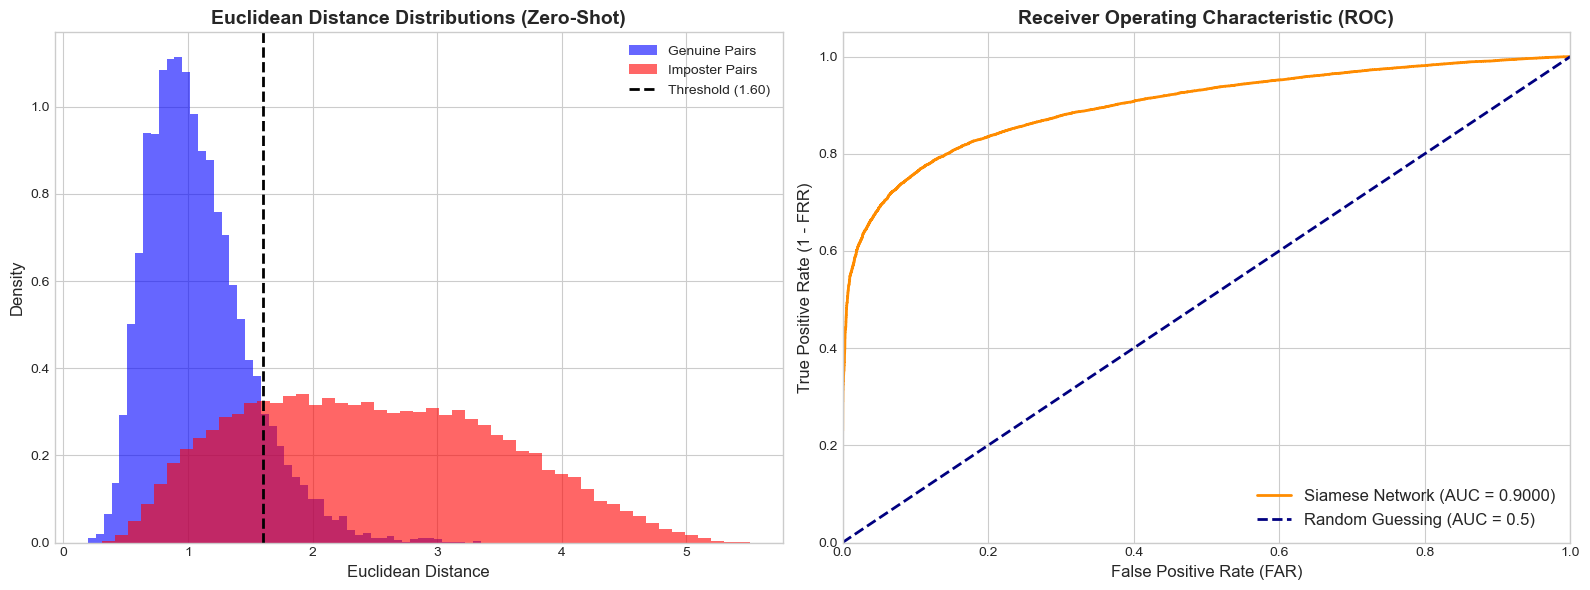


Graphs saved as: Aalto_HardMining_Tuned_Evaluation_Graphs.png
Optimal Security Threshold: 1.599


In [43]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

print("Loading Best Model Weights...")
model.load_state_dict(torch.load(f"{experiment_name}_best.pth"))
model.eval()

genuine_distances = []
imposter_distances = []

print("Extracting Euclidean distances from the Zero-Shot Validation Set...")

with torch.no_grad():
    for anchor, positive, negatives in val_loader:
        anchor = anchor.to(device)
        positive = positive.to(device)
        negatives = negatives.to(device)
        
        emb_a = model(anchor)
        emb_p = model(positive)
        
        dist_pos = F.pairwise_distance(emb_a, emb_p, p=2).cpu().numpy()
        genuine_distances.extend(dist_pos)
        
        batch_size, num_neg, seq, feats = negatives.shape
        negatives_flat = negatives.view(batch_size * num_neg, seq, feats)
        emb_n_all = model(negatives_flat)
        
        emb_n_all = emb_n_all.view(batch_size, num_neg, -1)
        
        distances = torch.cdist(emb_a.unsqueeze(1), emb_n_all).squeeze(1) # Shape: [batch, 5]
        
        imposter_distances.extend(distances.cpu().numpy().flatten())

genuine_distances = np.array(genuine_distances)
imposter_distances = np.array(imposter_distances)

y_true = np.concatenate([np.zeros(len(genuine_distances)), np.ones(len(imposter_distances))])
y_scores = np.concatenate([genuine_distances, imposter_distances])

fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

print(f"\n--- EVALUATION COMPLETE ---")
print(f"Total Genuine Pairs Evaluated: {len(genuine_distances)}")
print(f"Total Imposter Pairs Evaluated: {len(imposter_distances)}")
print(f"Calculated AUC: {roc_auc:.4f}")

plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.hist(genuine_distances, bins=50, alpha=0.6, color='blue', label='Genuine Pairs', density=True)
ax1.hist(imposter_distances, bins=50, alpha=0.6, color='red', label='Imposter Pairs', density=True)
ax1.set_title('Euclidean Distance Distributions (Zero-Shot)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Euclidean Distance', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.legend(loc='upper right', fontsize=11)

optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
ax1.axvline(x=optimal_threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold ({optimal_threshold:.2f})')
ax1.legend()

ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'Siamese Network (AUC = {roc_auc:.4f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing (AUC = 0.5)')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('False Positive Rate (FAR)', fontsize=12)
ax2.set_ylabel('True Positive Rate (1 - FRR)', fontsize=12)
ax2.set_title('Receiver Operating Characteristic (ROC)', fontsize=14, fontweight='bold')
ax2.legend(loc="lower right", fontsize=12)

plt.tight_layout()
plt.savefig(f"{experiment_name}_Evaluation_Graphs.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"\nGraphs saved as: {experiment_name}_Evaluation_Graphs.png")
print(f"Optimal Security Threshold: {optimal_threshold:.3f}")

--- Starting Sequence Length Ablation Study ---

Evaluating Sequence Length: 10 keystrokes...
Extracting sliding windows for Hard Mining...


-> Result: AUC = 0.8603

Evaluating Sequence Length: 15 keystrokes...
Extracting sliding windows for Hard Mining...
-> Result: AUC = 0.9052

Evaluating Sequence Length: 20 keystrokes...
Extracting sliding windows for Hard Mining...
-> Result: AUC = 0.9257

Evaluating Sequence Length: 25 keystrokes...
Extracting sliding windows for Hard Mining...
-> Result: AUC = 0.9356

Evaluating Sequence Length: 30 keystrokes...
Extracting sliding windows for Hard Mining...
-> Result: AUC = 0.9410

Evaluating Sequence Length: 40 keystrokes...
Extracting sliding windows for Hard Mining...
-> Result: AUC = 0.9458


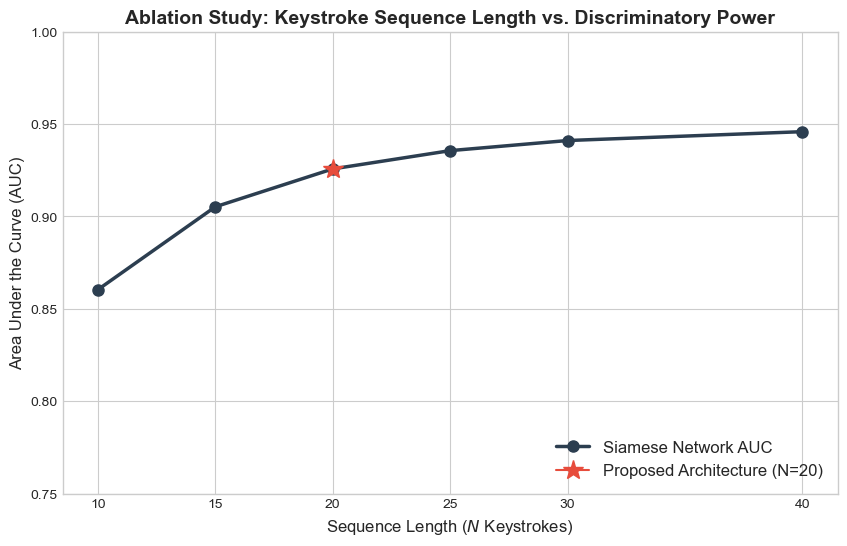


Ablation Study Complete. Graph saved as: Aalto_Ablation_Study.png


In [17]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

print("--- Starting Sequence Length Ablation Study ---")

sequence_lengths = [10, 15, 20, 25, 30, 40]
auc_scores = []

model = SiameseNetwork().to(device)
model.load_state_dict(torch.load("Aalto_HardMining_Tuned_best.pth"))
model.eval()

for seq_len in sequence_lengths:
    print(f"\nEvaluating Sequence Length: {seq_len} keystrokes...")
    
    val_dataset_ablation = HardMiningKeystrokeDataset(val_df, seq_length=seq_len, num_negatives=5)
    val_loader_ablation = DataLoader(val_dataset_ablation, batch_size=256, shuffle=False)
    
    genuine_distances = []
    imposter_distances = []
    
    with torch.no_grad():
        for anchor, positive, negatives in val_loader_ablation:
            anchor = anchor.to(device)
            positive = positive.to(device)
            negatives = negatives.to(device)
            
            # Genuine
            emb_a = model(anchor)
            emb_p = model(positive)
            genuine_distances.extend(F.pairwise_distance(emb_a, emb_p, p=2).cpu().numpy())
            
            # Imposters (Hard Mining shape)
            batch_size, num_neg, seq, feats = negatives.shape
            negatives_flat = negatives.view(batch_size * num_neg, seq, feats)
            emb_n_all = model(negatives_flat).view(batch_size, num_neg, -1)
            
            distances = torch.cdist(emb_a.unsqueeze(1), emb_n_all).squeeze(1)
            imposter_distances.extend(distances.cpu().numpy().flatten())

    y_true = np.concatenate([np.zeros(len(genuine_distances)), np.ones(len(imposter_distances))])
    y_scores = np.concatenate([genuine_distances, imposter_distances])
    
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    current_auc = auc(fpr, tpr)
    auc_scores.append(current_auc)
    
    print(f"-> Result: AUC = {current_auc:.4f}")

plt.figure(figsize=(10, 6))
plt.style.use('seaborn-v0_8-whitegrid')

plt.plot(sequence_lengths, auc_scores, marker='o', markersize=8, color='#2c3e50', linewidth=2.5, label='Siamese Network AUC')

baseline_idx = sequence_lengths.index(20)
plt.plot(20, auc_scores[baseline_idx], marker='*', markersize=15, color='#e74c3c', label='Proposed Architecture (N=20)')

plt.title('Ablation Study: Keystroke Sequence Length vs. Discriminatory Power', fontsize=14, fontweight='bold')
plt.xlabel('Sequence Length ($N$ Keystrokes)', fontsize=12)
plt.ylabel('Area Under the Curve (AUC)', fontsize=12)
plt.ylim(0.75, 1.0)
plt.xticks(sequence_lengths)
plt.legend(loc='lower right', fontsize=12)

plt.savefig("Aalto_Ablation_Study.png", dpi=300, bbox_inches='tight')
plt.show()

print("\nAblation Study Complete. Graph saved as: Aalto_Ablation_Study.png")